# Import Library

In [ ]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno

# Exploratory Data Analysis

## Get Dataset and Information

In [4]:
tmdb = pd.read_csv('tmdb_movie_database.csv')

display(tmdb.shape)
display(tmdb.head())
display(tmdb.describe())
tmdb.info()
display(tmdb.dtypes)

(1980, 10)

,title,year,runtime,genre_1,genre_2,director,score,user_ratings,budget,revenue
0,Avatar Aang: The Last Airbender,2026,99,Animation,Adventure,Lauren Montgomery,91,1113,-,-
1,Swapped,2026,102,Adventure,Animation,Nathan Greno,89,2175,$7,$7
2,Accidental Partners,2026,110,Comedy,Romance,Ihtzi Hurtado,89,378,-,-
3,Facing El Chapo,2026,91,Crime,Action,Chava Cartas,88,628,-,-
4,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025,156,Animation,Action,Haruo Sotozaki,88,2121,"$20,000,000","$733,030,221"


,year,runtime,score,user_ratings
count,1980.000000,1980.000000,1980.000000,1980.000000
mean,1998.114646,113.612626,77.269192,3756.758081
std,24.782948,31.841112,2.792967,5706.245988
min,1902.000000,4.000000,74.000000,300.000000
25%,1984.000000,97.000000,75.000000,584.750000
50%,2007.000000,112.000000,77.000000,1267.500000
75%,2018.000000,129.000000,79.000000,4030.750000
max,2026.000000,367.000000,91.000000,41125.000000


<class 'pandas.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   title         1980 non-null   str  
 1   year          1980 non-null   int64
 2   runtime       1980 non-null   int64
 3   genre_1       1980 non-null   str  
 4   genre_2       1635 non-null   str  
 5   director      1978 non-null   str  
 6   score         1980 non-null   int64
 7   user_ratings  1980 non-null   int64
 8   budget        1980 non-null   str  
 9   revenue       1980 non-null   str  
dtypes: int64(4), str(6)
memory usage: 154.8 KB


title             str
year            int64
runtime         int64
genre_1           str
genre_2           str
director          str
score           int64
user_ratings    int64
budget            str
revenue           str
dtype: object

## Fix Incorrect Data
Terlihat ada beberapa kesalahan, terutama tipe data budget dan revenue yang seharusnya float dan output kosong yang seharusnya NaN, sehingga harus diperbaiki terlbih dahulu

In [5]:
df = tmdb.copy()
for col in ["budget", "revenue"]:
    df[col] = pd.to_numeric(df[col].str.replace("$", "").str.replace(",", ""), errors="coerce")
for col in ["title", "genre_1", "genre_2", "director"]:
    df[col] = df[col].replace("", np.nan)

display(df.head())
display(df.dtypes.to_frame("After Clean"))
df.info()

,title,year,runtime,genre_1,genre_2,director,score,user_ratings,budget,revenue
0,Avatar Aang: The Last Airbender,2026,99,Animation,Adventure,Lauren Montgomery,91,1113,NaN,NaN
1,Swapped,2026,102,Adventure,Animation,Nathan Greno,89,2175,7.0,7.0
2,Accidental Partners,2026,110,Comedy,Romance,Ihtzi Hurtado,89,378,NaN,NaN
3,Facing El Chapo,2026,91,Crime,Action,Chava Cartas,88,628,NaN,NaN
4,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025,156,Animation,Action,Haruo Sotozaki,88,2121,20000000.0,733030221.0


,After Clean
title,str
year,int64
runtime,int64
genre_1,str
genre_2,str
director,str
score,int64
user_ratings,int64
budget,float64
revenue,float64


<class 'pandas.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1980 non-null   str    
 1   year          1980 non-null   int64  
 2   runtime       1980 non-null   int64  
 3   genre_1       1980 non-null   str    
 4   genre_2       1635 non-null   str    
 5   director      1978 non-null   str    
 6   score         1980 non-null   int64  
 7   user_ratings  1980 non-null   int64  
 8   budget        1269 non-null   float64
 9   revenue       1436 non-null   float64
dtypes: float64(2), int64(4), str(4)
memory usage: 154.8 KB


## Attribute Types
- `title`, `genre_1`, `genre_2`, `director`: nominal.
- `year`, `runtime`, `score`, `user_ratings`: numerik diskrit.
- `budget`, `revenue`: numerik kontinu.
- Tidak ada data ordinal

## Statistik Deskriptif

In [6]:
numeric = ["year", "runtime", "score", "user_ratings", "budget", "revenue"]
statistik = pd.DataFrame({
    "count": df[numeric].count(),
    "rata-rata": df[numeric].mean(),
    "median": df[numeric].median(),
    "modus": df[numeric].mode().iloc[0],
    "standar deviasi": df[numeric].std(),
    "minimum": df[numeric].min(),
    "maksimum": df[numeric].max()
})
display(statistik.round(2))

for col in ["genre_1", "genre_2", "director"]:
    data = df[col].fillna("Tidak tersedia")
    count = data.value_counts()
    frequency = data.value_counts(normalize=True) * 100
    unique = data.nunique()
    modus = data.mode().iloc[0]
    print(f"\nDistribusi {col}")
    print(f"Unique : {unique}")
    print(f"Modus  : {modus}")
    display(pd.DataFrame({
        "count": count,
        "frequency (%)": frequency.round(2)
        }))


,count,rata-rata,median,modus,standar deviasi,minimum,maksimum
year,1980,1.998110e+03,2007.0,2019.0,2.478000e+01,1902.0,2.026000e+03
runtime,1980,1.136100e+02,112.0,100.0,3.184000e+01,4.0,3.670000e+02
score,1980,7.727000e+01,77.0,75.0,2.790000e+00,74.0,9.100000e+01
user_ratings,1980,3.756760e+03,1267.5,390.0,5.706250e+03,300.0,4.112500e+04
budget,1269,3.256239e+07,11983950.0,15000000.0,5.328388e+07,1.0,4.600000e+08
revenue,1436,1.374475e+08,30596940.5,10000000.0,2.897367e+08,6.0,2.923706e+09



Distribusi genre_1
Unique : 19
Modus  : Drama


,count,frequency (%)
genre_1,,
Drama,677,34.19
Animation,232,11.72
Comedy,231,11.67
Action,171,8.64
Crime,101,5.10
Adventure,100,5.05
Documentary,84,4.24
Romance,68,3.43
Thriller,48,2.42



Distribusi genre_2
Unique : 20
Modus  : Drama


,count,frequency (%)
genre_2,,
Drama,360,18.18
Tidak tersedia,345,17.42
Romance,163,8.23
Comedy,140,7.07
Thriller,136,6.87
Crime,106,5.35
History,95,4.80
Action,90,4.55
Family,90,4.55



Distribusi director
Unique : 1206
Modus  : Akira Kurosawa


,count,frequency (%)
director,,
Akira Kurosawa,15,0.76
Steven Spielberg,14,0.71
Alfred Hitchcock,14,0.71
Hayao Miyazaki,12,0.61
Martin Scorsese,12,0.61
...,...,...
Xavier Giannoli,1,0.05
David Silverman,1,0.05
Lina Wertmüller,1,0.05


## Missing Values

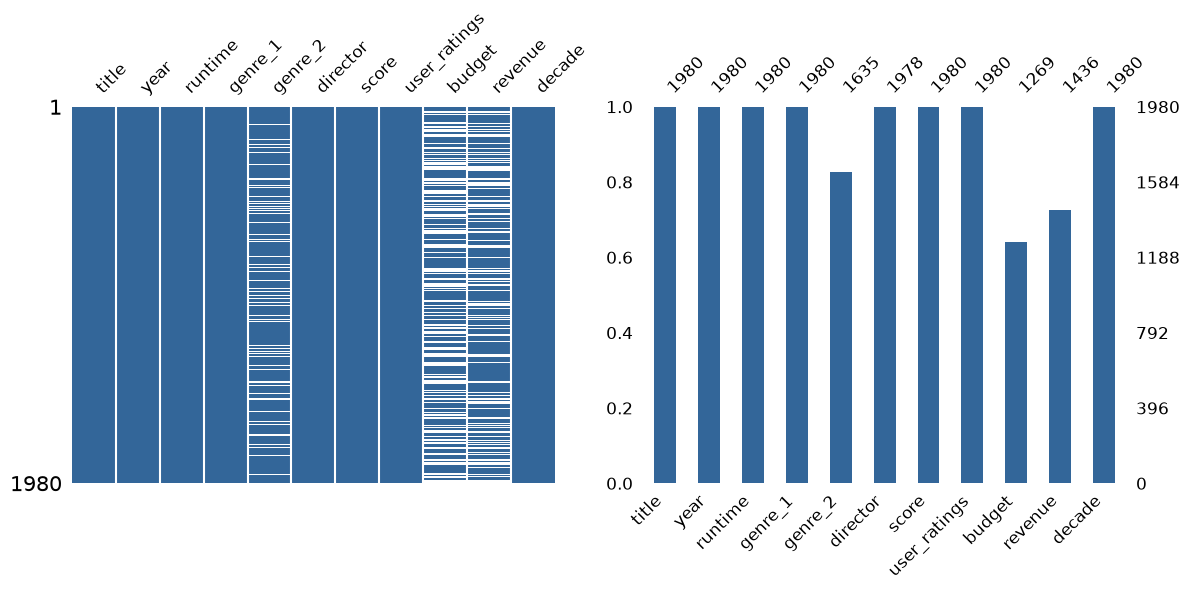

In [21]:
fig, axes = plt.subplots(1,2,figsize=(12,6))
axes = axes.flatten()

msno.matrix(df, ax=axes[0], fontsize=12, color=(0.2, 0.4, 0.6), sparkline=False)
msno.bar(df, ax=axes[1], fontsize=12, color=(0.2, 0.4, 0.6))
plt.savefig("missingplot.png", dpi=300)
plt.tight_layout()

Missing values pada budget dan revenue tampak memiliki pola yang serupa, yang mengindikasikan adanya keterkaitan sumber data atau proses pelaporan informasi finansial film. Tidak semua film mempublikasikan informasi biaya produksi maupun pendapatannya. Fenomena ini umumnya terjadi pada film independen, film lama, film dengan distribusi terbatas, atau film yang tidak memiliki data finansial yang terdokumentasi secara lengkap pada TMDb

## Outliers

In [7]:
def outliers(seri):
    q1, q3 = seri.quantile(.25), seri.quantile(.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    check = (seri < lower) | (seri > upper)
    return lower, upper, check, q1, q3

outlier = []
for i in numeric:
    seri = df[i].dropna()
    bawah, atas, check, q1, q3 = outliers(seri)
    outlier.append({"atribut": i,
                    "Q1": q1,
                    "Q3": q3,
                    "lower": round(bawah, 2), "upper": round(atas, 2),
                    "jumlah outlier": int(check.sum()),
                    "persen": round(check.mean() * 100, 2)})
pd.DataFrame(outlier)

,atribut,Q1,Q3,lower,upper,jumlah outlier,persen
0,year,1984.00,2.018000e+03,1.933000e+03,2.069000e+03,32,1.62
1,runtime,97.00,1.290000e+02,4.900000e+01,1.770000e+02,127,6.41
2,score,75.00,7.900000e+01,6.900000e+01,8.500000e+01,13,0.66
3,user_ratings,584.75,4.030750e+03,-4.584250e+03,9.199750e+03,253,12.78
4,budget,3000000.00,3.400000e+07,-4.350000e+07,8.050000e+07,159,12.53
5,revenue,5632847.75,1.198176e+08,-1.656443e+08,2.910948e+08,195,13.58


Outlier yang ada tidak akan dihapus atau dimanipulasi dengan alasan bahwa para outlier masih merepresentasikan kondisi yang valid pada dunia nyata. Sebagai contoh, film _Lord of the Rings: Return of the King_ yang menempati posisi 18 film rating tertinggi dikategorikan outlier berdasarkan `runtime` (201 menit), `user_ratings` (27k), `budget` (94 juta), dan `revenue` (1 milyar) dan kasus ini terjadi pada kebanyakan film.

In [58]:
checks = {
    "Invalid year": (df["year"] < 1888) | (df["year"] > 2026),
    "Invalid runtime": df["runtime"] <= 0,
    "Invalid score": (df["score"] < 0) | (df["score"] > 100),
    "Invalid budget": df["budget"] < 0,
    "Invalid revenue": df["revenue"] < 0,
    "Invalid user ratings": df["user_ratings"] < 0
}

display(pd.Series({key: value.sum() for key, value in checks.items()}))

Invalid year            0
Invalid runtime         0
Invalid score           0
Invalid budget          0
Invalid revenue         0
Invalid user ratings    0
dtype: int64

Tidak adanya data invalid menandakan bahwa data tidak ada data aneh

## Duplicates

In [57]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate titles:", df["title"].duplicated().sum())

Duplicate rows: 0
Duplicate titles: 16


Untuk duplicate, sebenarnya tidak ada yang duplicate berdasarkan ketentuan website. Duplicate pada title itu kebanyakan film-film remake, contohnya _All Quiet in the Western Front_ yang memiliki 2 film yaitu pada 1930 dan remakenya pada 2022

# Visualization

## Univariate

### Numerical Distribution

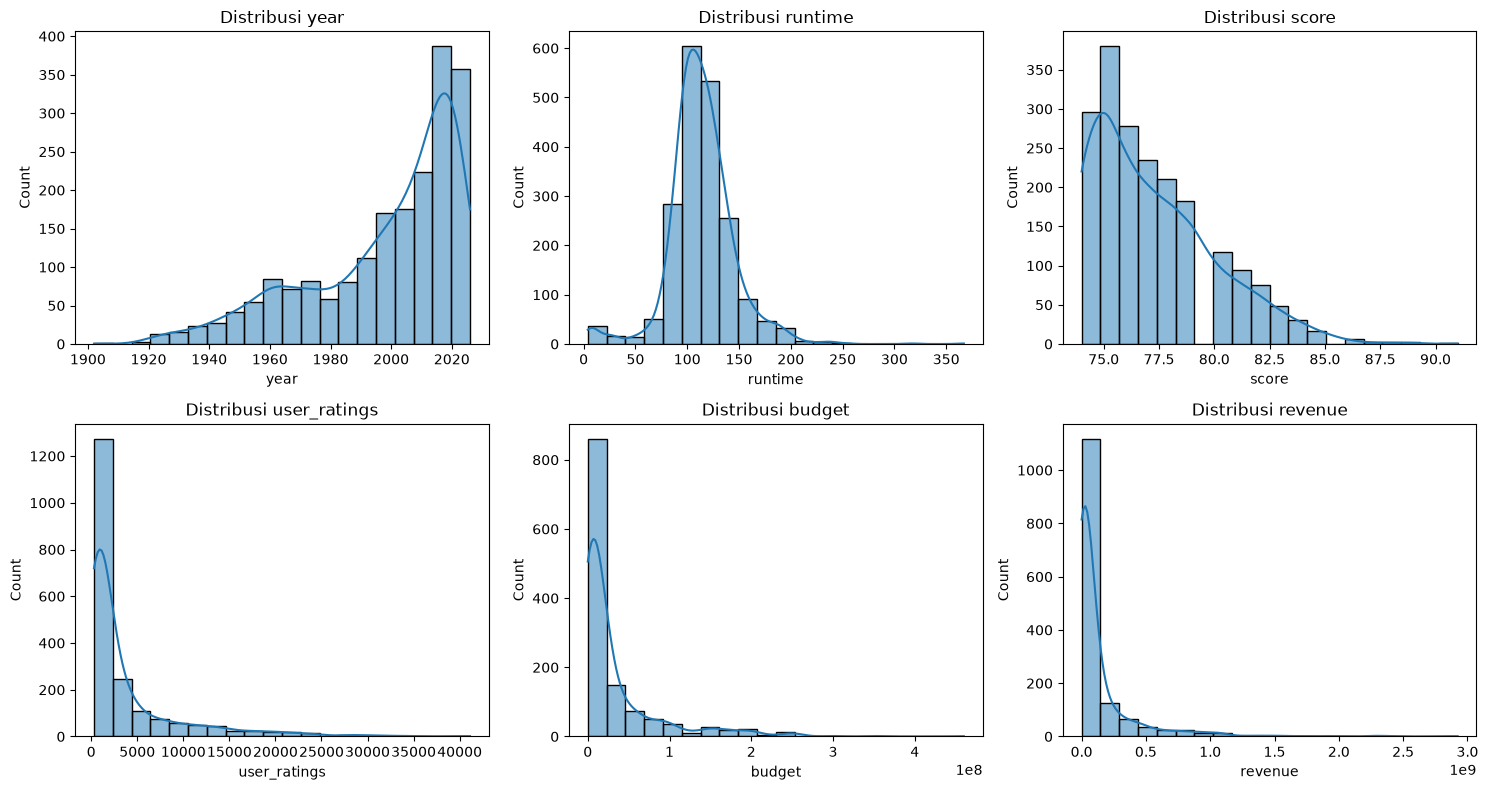

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric):
    values = df.loc[df[col] > 0, col].dropna()
    sb.histplot(values, bins=20, kde=True, ax=ax)
    ax.set_xlabel(col)
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.savefig("numericalpre.png", dpi=300)
plt.show()


Untuk distribusi `user-ratings`, `budget`, dan `reveue`, data yang diperoleh sangat right skewed, sehingga perlu di-replot log

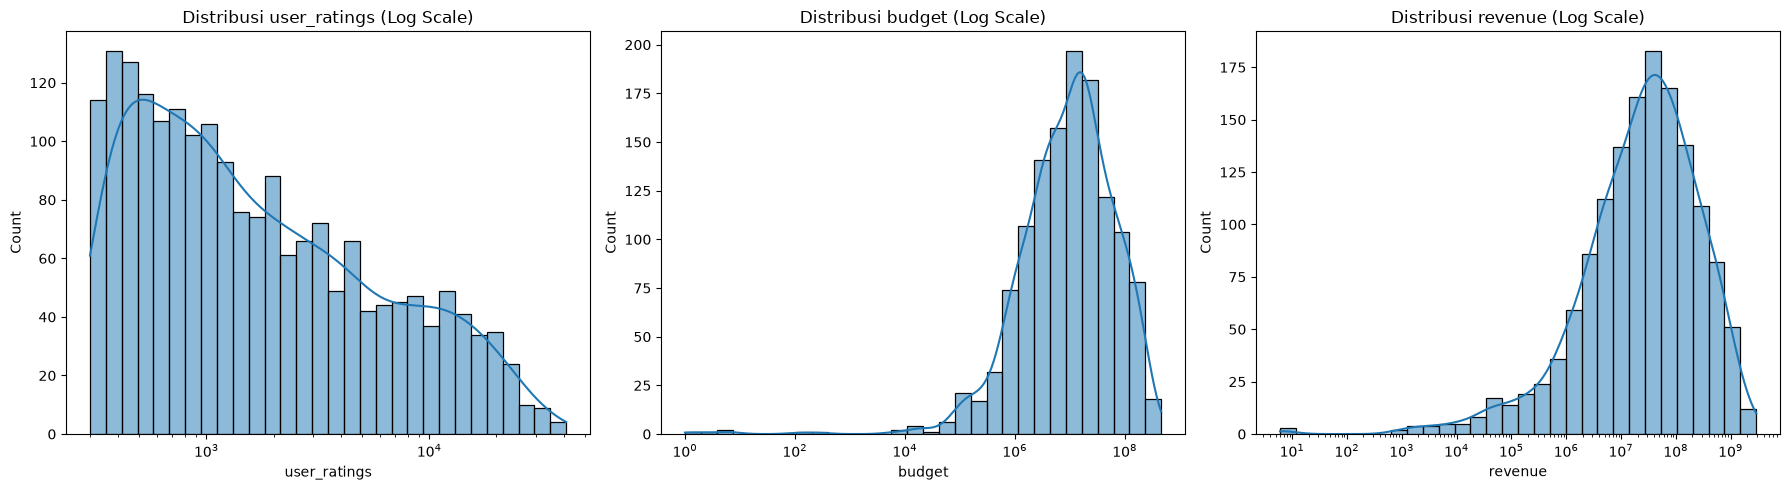

In [29]:
log = ["user_ratings", "budget", "revenue"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for ax, col in zip(axes, log):
    values = df.loc[df[col] > 0, col].dropna()
    sb.histplot(values, bins=30, kde=True, ax=ax, log_scale=True)
    ax.set_title(f"Distribusi {col} (Log Scale)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("numericalpost.png", dpi=300)
plt.show()

Skala log membantu memperjelas pola pada data yang sangat right-skewed

### Categorical Distribution

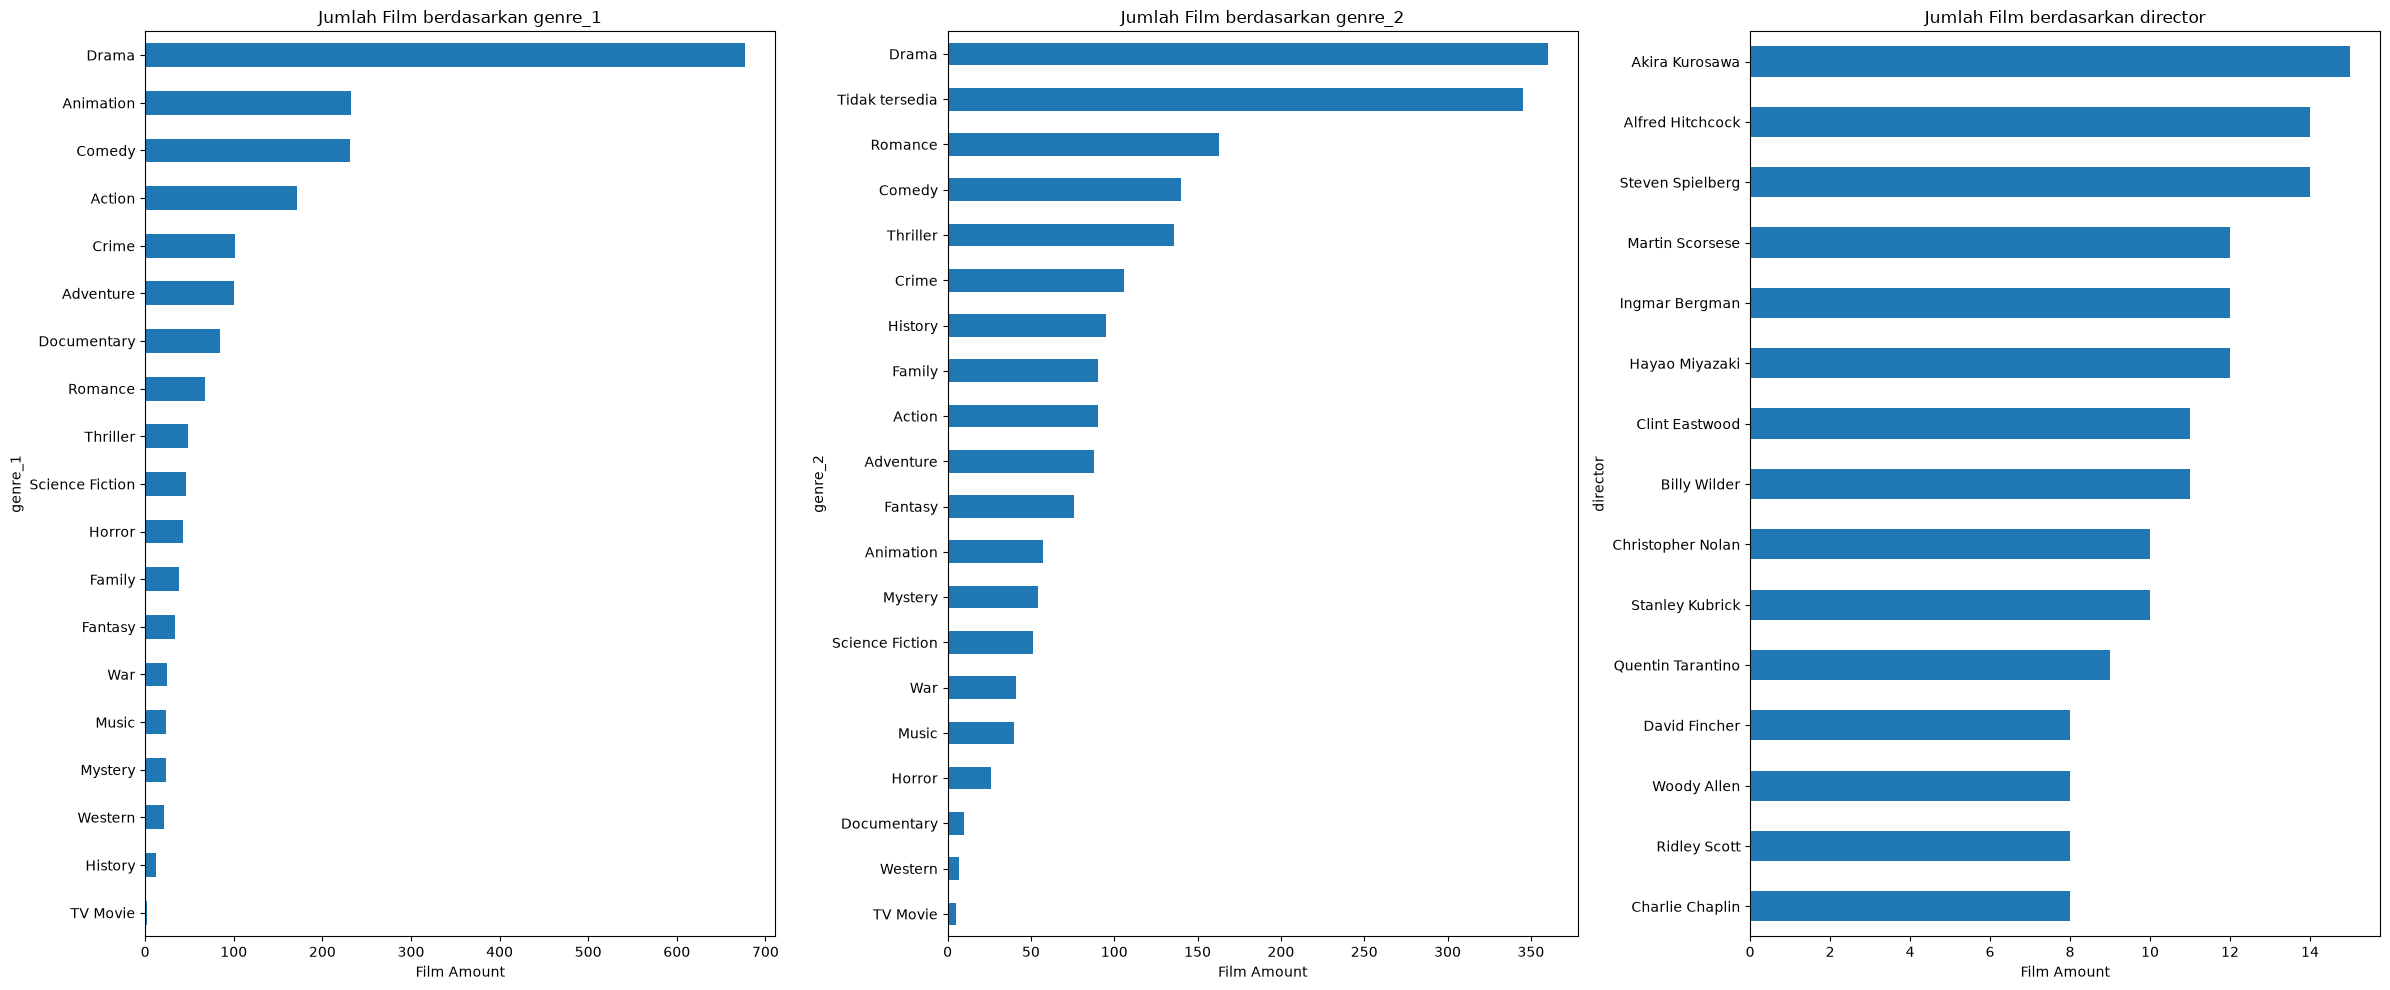

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
axes = axes.flatten()

for ax, col in zip(axes, ["genre_1", "genre_2", "director"]):
    vc = df[col].fillna("Tidak tersedia").value_counts()
    if col == "director":
        vc = vc.head(15)
    vc = vc.sort_values()
    vc.plot(kind="barh", ax=ax)
    ax.set_title(f"Jumlah Film berdasarkan {col}")
    ax.set_xlabel("Film Amount")
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig("topcat.png", dpi=300)
plt.show()

Drama mendominasi genre 1 dan genre 2, dan direktur dengan film top rated terbanyak adalah Akira Kurosawa, yang terkenal dengan film _Ran_, _Seven Samurai_, _Ikiru_ dan _High and Low_ 

## Bivariate

### Numerical vs Numerical

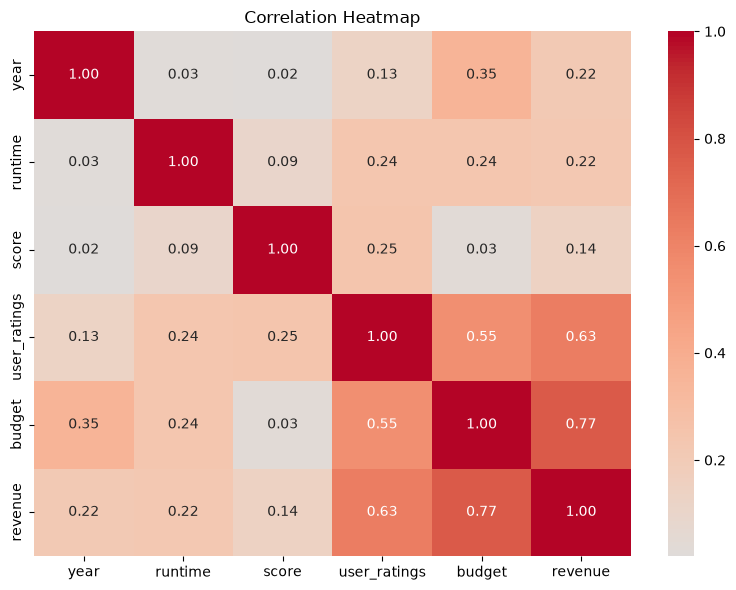

,level_0,level_1,0
0,budget,revenue,0.770393
1,user_ratings,revenue,0.632402
2,user_ratings,budget,0.545398


In [34]:
corr = df[numeric].corr()
plt.figure(figsize=(8,6))
sb.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("corrmatrix.png", dpi=300)
plt.show()
top_3_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().abs().nlargest(3).reset_index()
display(top_3_corr)

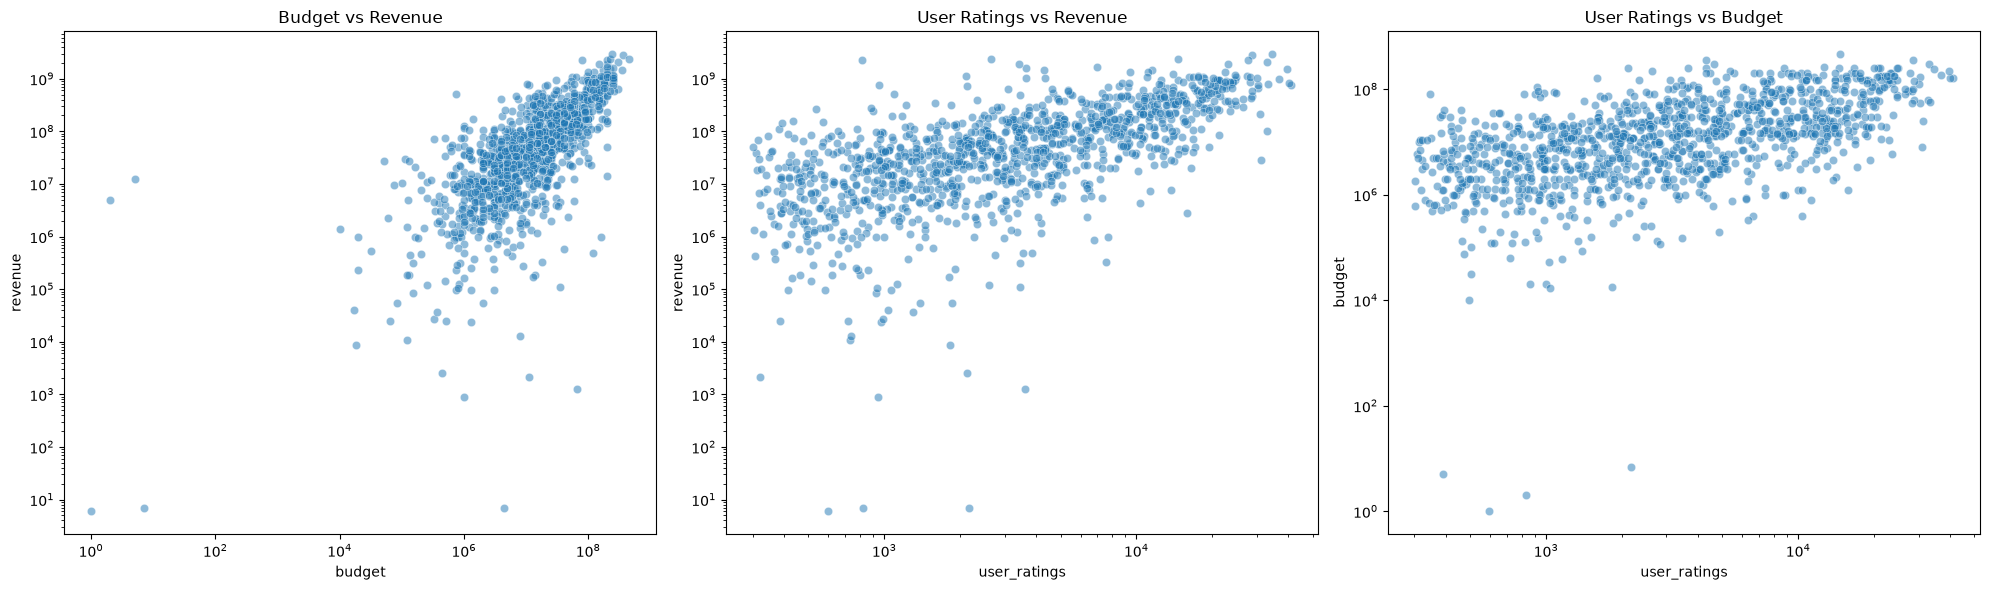

In [ ]:
valid = df[(df["budget"] > 0) & (df["revenue"] > 0) & (df["user_ratings"] > 0)]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plots = [
    ("budget", "revenue", "Budget vs Revenue"),
    ("user_ratings", "revenue", "User Ratings vs Revenue"),
    ("user_ratings", "budget", "User Ratings vs Budget")
]

for ax, (x, y, title) in zip(axes, plots):
    sb.scatterplot(data=valid, x=x, y=y, alpha=0.5, ax=ax)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("compare.png", dpi=300)
plt.show()

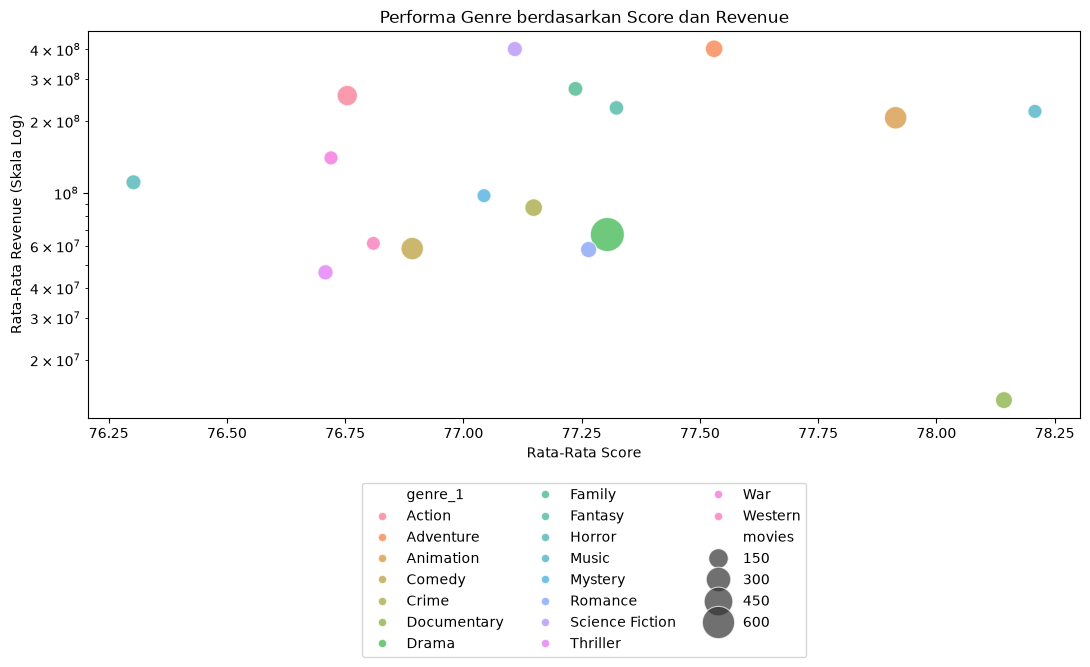

In [55]:
genre_summary = df.groupby("genre_1").agg(movies=("title", "count"), avg_score=("score", "mean"), avg_revenue=("revenue", "mean")).query("movies >= 20").reset_index()
fig, axes = plt.subplots(figsize=(11, 7))
sb.scatterplot(data=genre_summary, x="avg_score", y="avg_revenue", size="movies", hue="genre_1", sizes=(100, 600), alpha=0.7, ax=axes)
axes.set_yscale("log")
axes.set_title("Performa Genre berdasarkan Score dan Revenue")
axes.set_xlabel("Rata-Rata Score")
axes.set_ylabel("Rata-Rata Revenue (Skala Log)")
axes.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
plt.tight_layout()
plt.savefig("genre.png", dpi=300)
plt.show()

### Categorical vs Numerical

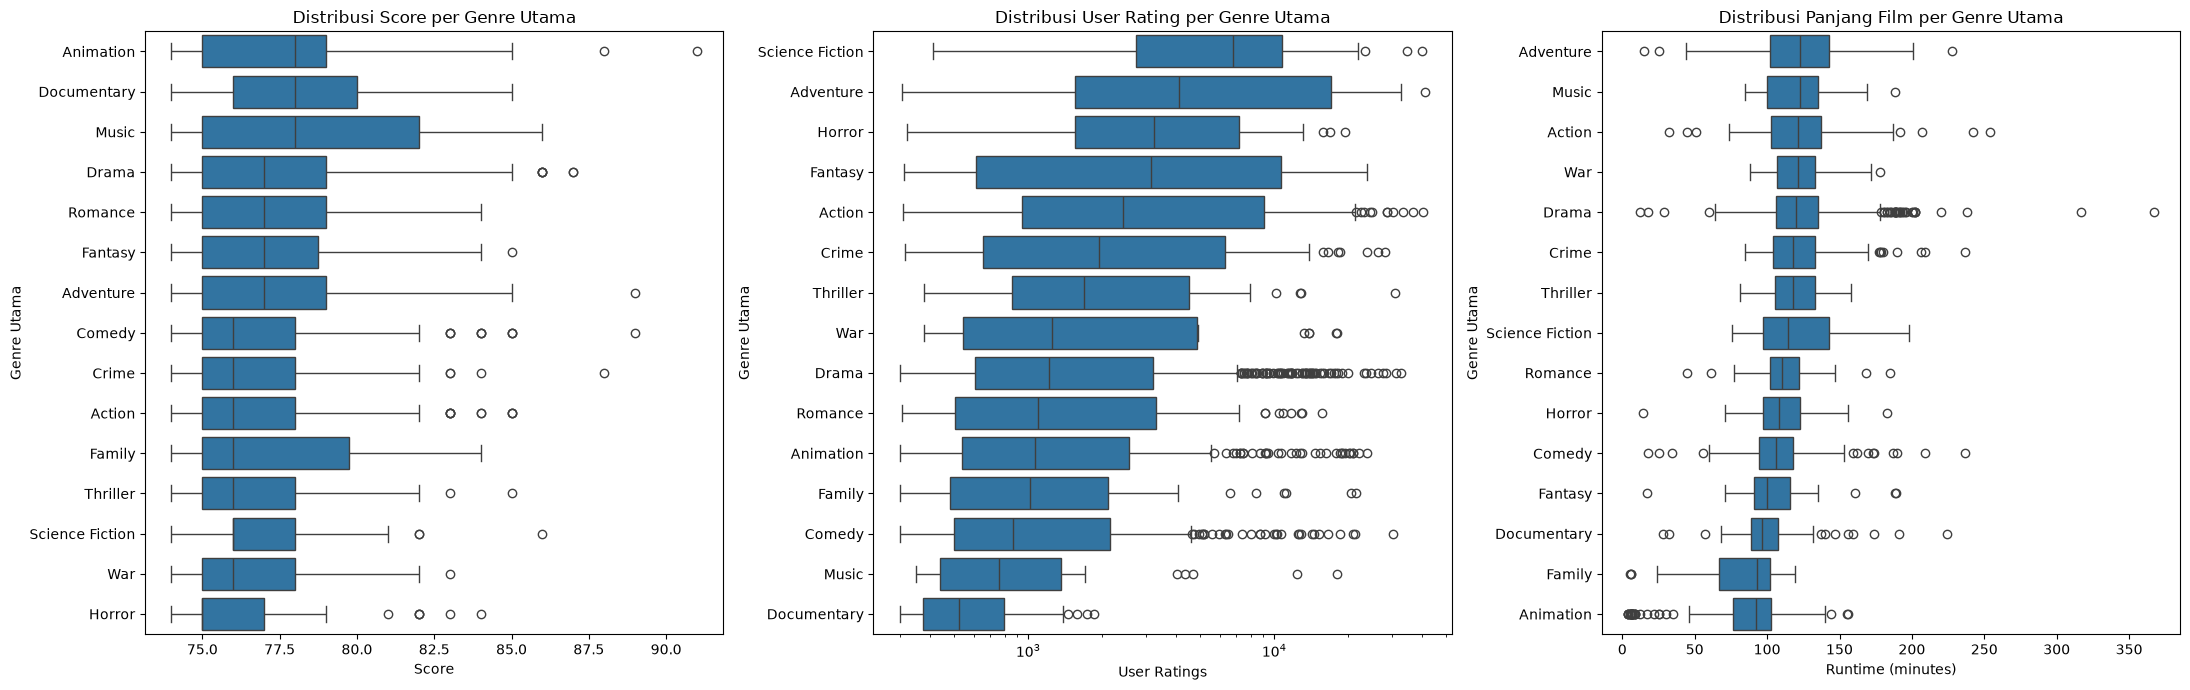

In [44]:
top = df["genre_1"].value_counts().head(15).index

plots = [
    (df[df["genre_1"].isin(top)], "score", "Score", "Distribusi Score per Genre Utama", False),
    (df[(df["genre_1"].isin(top)) & (df["user_ratings"] > 0)], "user_ratings", "User Ratings", "Distribusi User Rating per Genre Utama", True),
    (df[(df["genre_1"].isin(top)) & (df["runtime"] > 0)], "runtime", "Runtime (minutes)", "Distribusi Panjang Film per Genre Utama", False)
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
axes = axes.flatten()

for ax, (data, x, xlabel, title, log_scale) in zip(axes, plots):
    order = data.groupby("genre_1")[x].median().sort_values(ascending=False).index
    sb.boxplot(data=data, x=x, y="genre_1", order=order, ax=ax)
    if log_scale:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Genre Utama")
plt.tight_layout()
plt.savefig("distribusi.png", dpi=300)
plt.show()

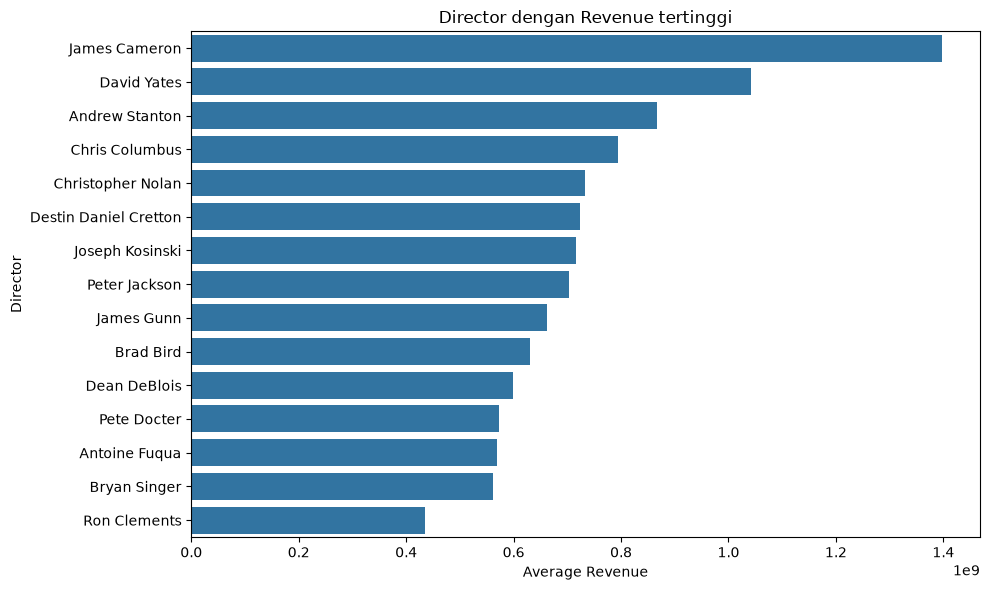

In [45]:
director_avg = (df.groupby("director").agg(movies=("title", "count"),avg_revenue=("revenue", "mean")).query("movies >= 3").sort_values("avg_revenue", ascending=False).head(15))
plt.figure(figsize=(10, 6))
sb.barplot(data=director_avg,x="avg_revenue",y="director",)
plt.title("Director dengan Revenue tertinggi")
plt.xlabel("Average Revenue")
plt.ylabel("Director")
plt.tight_layout()
plt.savefig("directormoney.png", dpi=300)
plt.show()

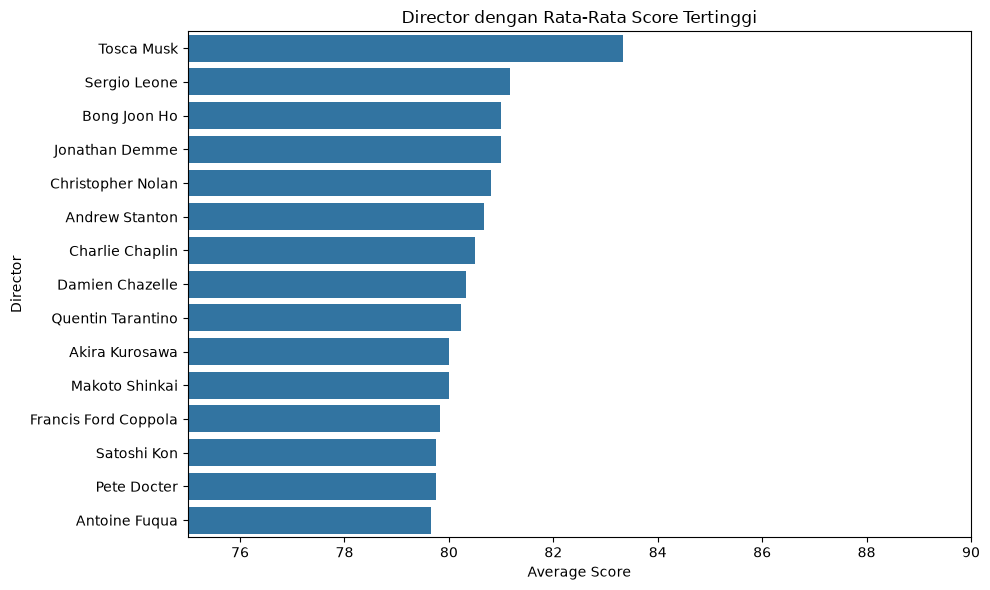

In [46]:
director_avg = df.groupby("director").agg(movies=("title", "count"), avg_score=("score", "mean")).query("movies >= 3").sort_values("avg_score", ascending=False).head(15).reset_index()
plt.figure(figsize=(10, 6))
sb.barplot(data=director_avg, x="avg_score", y="director")
plt.title("Director dengan Rata-Rata Score Tertinggi")
plt.xlabel("Average Score")
plt.ylabel("Director")
plt.xlim(75, 90)
plt.tight_layout()
plt.savefig("directorscore.png", dpi=300)
plt.show()

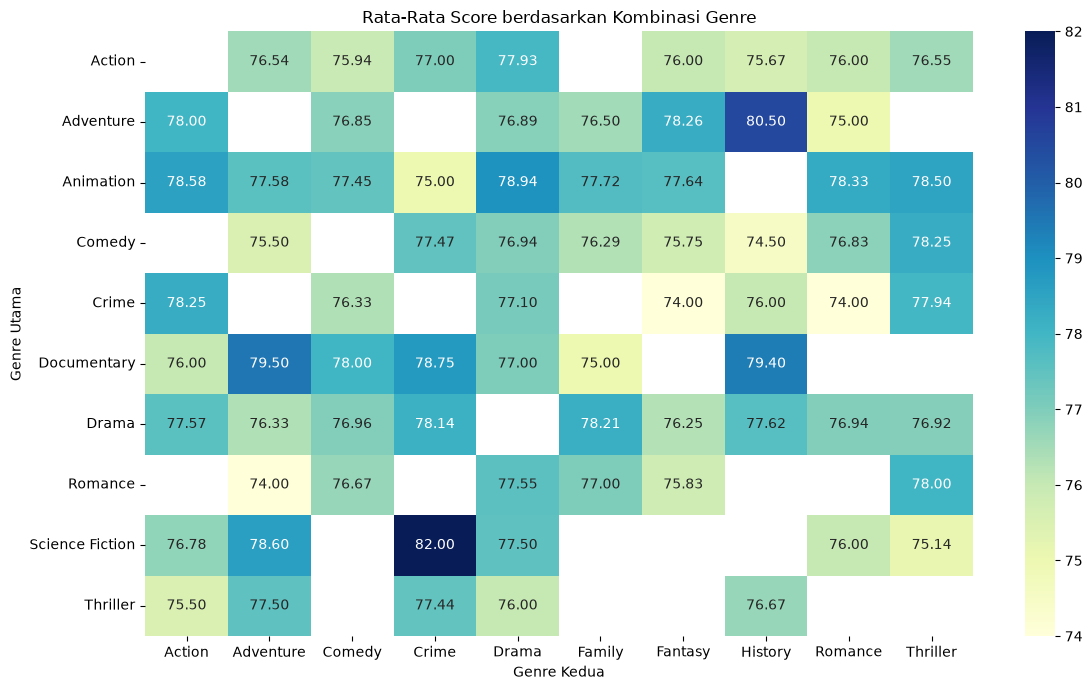

In [54]:
top_genre_1 = df["genre_1"].value_counts().head(10).index
top_genre_2 = df["genre_2"].value_counts().head(10).index
genre_score = df[df["genre_1"].isin(top_genre_1) &df["genre_2"].isin(top_genre_2)].pivot_table(index="genre_1", columns="genre_2", values="score", aggfunc="mean")
plt.figure(figsize=(12, 7))
sb.heatmap(genre_score, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Rata-Rata Score berdasarkan Kombinasi Genre")
plt.xlabel("Genre Kedua")
plt.ylabel("Genre Utama")
plt.tight_layout()
plt.savefig("genremap.png", dpi=300)
plt.show()

## Multivariat

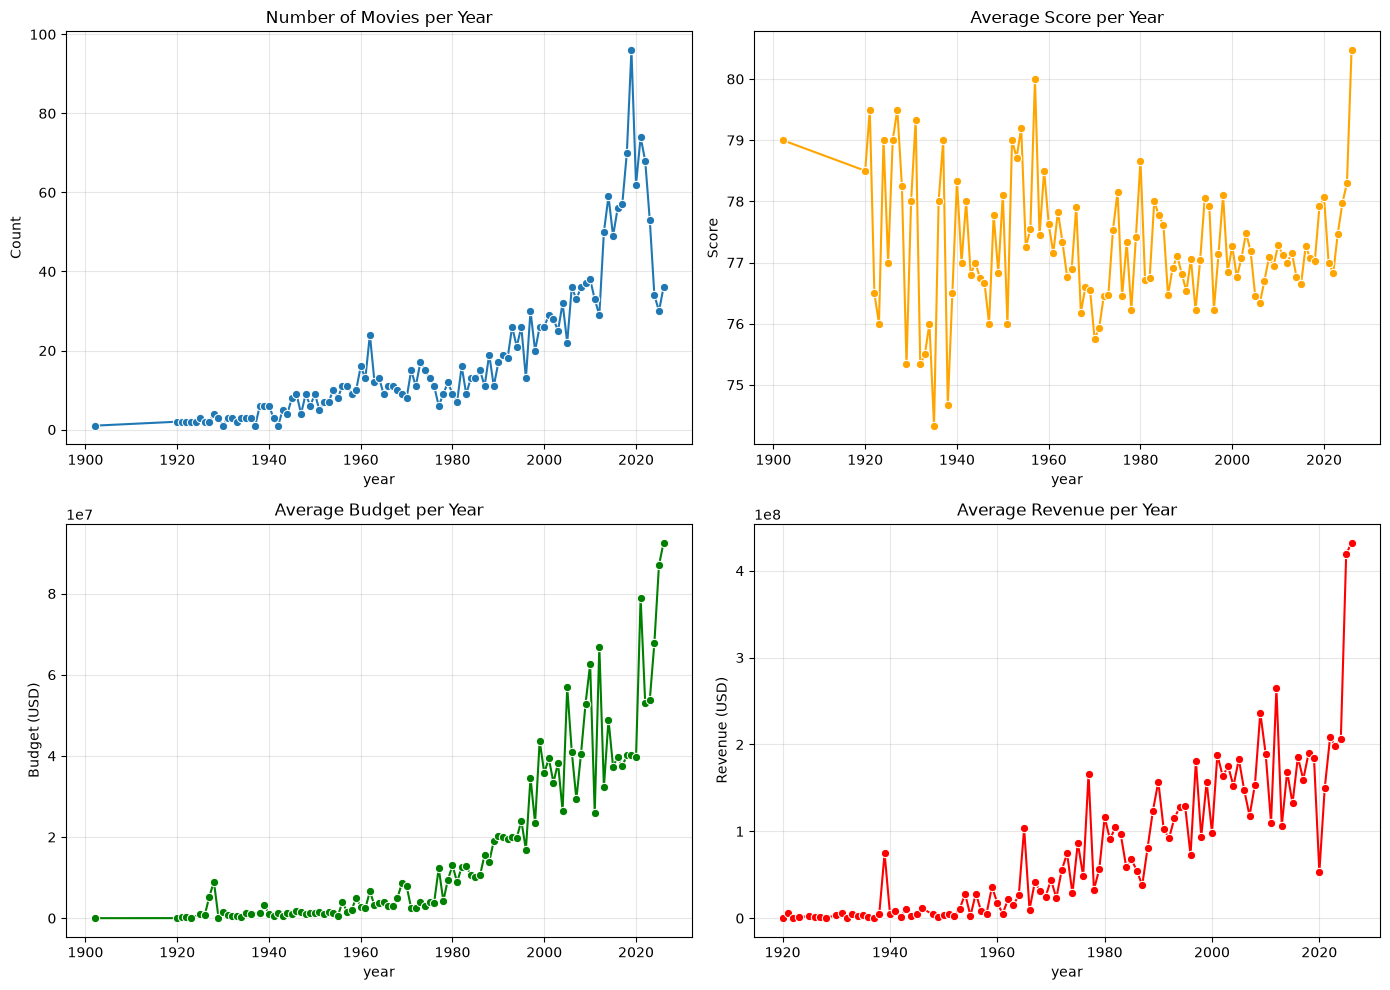

In [60]:
yearly = df.groupby("year").agg(n_movies=("title", "count"), avg_score=("score", "mean"), avg_budget=("budget", "mean"), avg_revenue=("revenue", "mean")).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sb.lineplot(data=yearly, x="year", y="n_movies", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Number of Movies per Year")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(True, alpha=0.3)

sb.lineplot(data=yearly, x="year", y="avg_score", marker="o", color="orange", ax=axes[0, 1])
axes[0, 1].set_title("Average Score per Year")
axes[0, 1].set_ylabel("Score")
axes[0, 1].grid(True, alpha=0.3)

sb.lineplot(data=yearly, x="year", y="avg_budget", marker="o", color="green", ax=axes[1, 0])
axes[1, 0].set_title("Average Budget per Year")
axes[1, 0].set_ylabel("Budget (USD)")
axes[1, 0].grid(True, alpha=0.3)

sb.lineplot(data=yearly, x="year", y="avg_revenue", marker="o", color="red", ax=axes[1, 1])
axes[1, 1].set_title("Average Revenue per Year")
axes[1, 1].set_ylabel("Revenue (USD)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("yearly.png", dpi=300)
plt.show()